### Lab: Navigating the Lunar Lander with a Dueling Deep Q Network

### University of Virginia
### Reinforcement Learning
#### Last updated: October 28, 2025

---
#### Student: Pranav Sridhar
#### Computing ID: ps2pw
---

#### Instructions:

You will work with the `LunarLander-v3` environment from `gymnasium` in this lab.  

An overview of the environment can be found [here](https://gymnasium.farama.org/).  
If you're curious about the source code, see [here](https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/box2d/lunar_lander.py).

Your mission will be to implement a dueling deep Q -network using PyTorch.  
You might run this on Colab.

There are a few specific tasks outlined below for you to solve.

The bigger tasks will be to:

- Show that the algorithm works to train the agent in the environment
- Run episodes and show the results

**Submission**  
As you will likely have several files including this notebook, you can zip all files and submit.

---

![lunar](./lunar_lander1.png)

#### TOTAL POINTS: 12

---

**Hint:** Modules you may need to install include:

swig  
gym[box2d]  
gymnasium

#### 1) What is the penalty for crashing?  
**(POINTS: 1)**


Crashing gives a penalty of -100.

#### 2) Set up the environment and run 2 steps by taking random actions.
**(POINTS: 1)**

In [8]:
import gymnasium as gym

env = gym.make("LunarLander-v3")
state, info = env.reset(seed=42)
for step in range(2):
    action = env.action_space.sample()  # random action
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print(f"step {step}: action={action}, state={state}, reward={reward:.2f}, done={done}")
    if terminated or truncated:
        state, info = env.reset()

env.close()

step 0: action=1, state=[ 0.00449829  1.4247646   0.22032492  0.294843   -0.00285054 -0.00391279
  0.          0.        ], reward=2.08, done=False
step 1: action=2, state=[ 6.7503927e-03  1.4321916e+00  2.2517133e-01  3.3008507e-01
 -2.8146501e-03  7.1823277e-04  0.0000000e+00  0.0000000e+00], reward=-4.19, done=False


#### 3) Briefly discuss your approach to solving the problem  
**(POINTS: 2)**

For the assignment, I'll take my DQN and split its output layer into two branches: one that learns how good the current state is (value), and one that learns how much better each action is compared to the others (advantage). I'll add these together to get the final Q-values, then train it the normal DQN way — replay buffer, epsilon-greedy, target network — and track reward and loss in TensorBoard to see if it solves LunarLander (reward ≥200) faster than a regular DQN.

#### 4) Create supporting code files (`.py` format) to create the agent, train, and run episodes
**(POINTS: 6)**

Your code should include:

- **(POINTS: 1)** A class for the dueling DQN agent 
- **(POINTS: 1)** An architecture with separate Value and Advantage streams
- **(POINTS: 1)** A method called `forward()` for the forward pass of the algorithm
- **(POINTS: 1)** A replay buffer
- **(POINTS: 1)** A training function
- **(POINTS: 1)** A function to run episodes

#### 5) Run the training and show evidence that the agent is learning.  

For example, its average reward (score) should increase with more episodes.

**(POINTS: 1 if successful)**

episode 20/200 | avg reward (last 20): -169.0 | epsilon: 0.905
episode 40/200 | avg reward (last 20): -104.1 | epsilon: 0.818
episode 60/200 | avg reward (last 20): -82.6 | epsilon: 0.740
episode 80/200 | avg reward (last 20): -70.6 | epsilon: 0.670
episode 100/200 | avg reward (last 20): -64.2 | epsilon: 0.606
episode 120/200 | avg reward (last 20): -40.1 | epsilon: 0.548
episode 140/200 | avg reward (last 20): -72.8 | epsilon: 0.496
episode 160/200 | avg reward (last 20): -26.7 | epsilon: 0.448
episode 180/200 | avg reward (last 20): -6.8 | epsilon: 0.406
episode 200/200 | avg reward (last 20): 8.6 | epsilon: 0.367


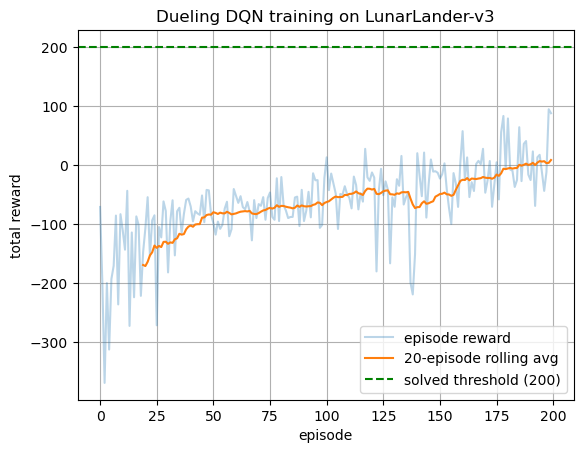

avg reward, first 20 episodes: -169.02122985251825
avg reward, last 20 episodes: 8.591169496741475


In [13]:
from train import train_dueling_dqn, run_episodes
import numpy as np
import matplotlib.pyplot as plt

agent, episode_rewards = train_dueling_dqn(
    env_name="LunarLander-v3",
    num_episodes=200,
    max_steps=1000,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    lr=5e-4,
    gamma=0.99,
    tau=0.005,
    batch_size=64,
)

window = 20
rolling_avg = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")

plt.plot(episode_rewards, alpha=0.3, label="episode reward")
plt.plot(range(window - 1, len(episode_rewards)), rolling_avg, label=f"{window}-episode rolling avg")
plt.axhline(200, color="green", linestyle="--", label="solved threshold (200)")
plt.xlabel("episode")
plt.ylabel("total reward")
plt.title("Dueling DQN training on LunarLander-v3")
plt.legend()
plt.grid()
plt.show()

print("avg reward, first 20 episodes:", np.mean(episode_rewards[:20]))
print("avg reward, last 20 episodes:", np.mean(episode_rewards[-20:]))

#### 6) Run a few episodes and show results
**(POINTS: 1 if successful)**

episode 1: reward = 11.4
episode 2: reward = -4.2
episode 3: reward = -1.4
episode 4: reward = -3.2
episode 5: reward = 260.2

min: -4.2  mean: 52.5  max: 260.2


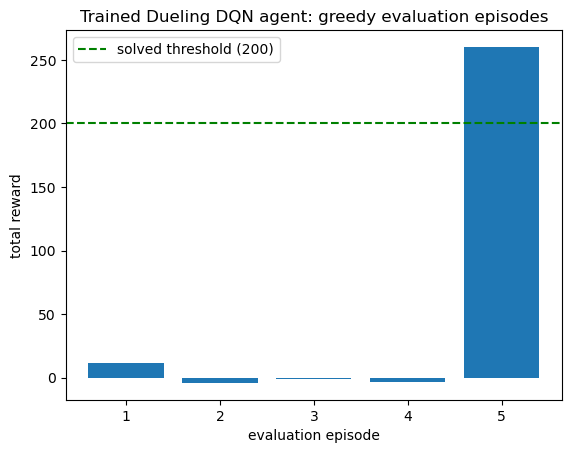

In [14]:
eval_rewards = run_episodes(agent, env_name="LunarLander-v3", num_episodes=5, epsilon=0.0)

plt.bar(range(1, len(eval_rewards) + 1), eval_rewards)
plt.axhline(200, color="green", linestyle="--", label="solved threshold (200)")
plt.xlabel("evaluation episode")
plt.ylabel("total reward")
plt.title("Trained Dueling DQN agent: greedy evaluation episodes")
plt.legend()
plt.show()